In [1]:
# ============================================================================
# CELL 1: Import Libraries and Load Data
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split

# Set seed for reproducibility
np.random.seed(42)
sns.set_style("whitegrid")

# Load the dataset
df = pd.read_csv("../titanic3.csv")

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Dataset shape: (1309, 14)

First 5 rows:


,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.00,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.92,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.00,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.00,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.00,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


In [2]:
X = df.drop(columns=["survived"])
y = df["survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [3]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 1047 entries, 999 to 668
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pclass     1047 non-null   int64  
 1   name       1047 non-null   str    
 2   sex        1047 non-null   str    
 3   age        838 non-null    float64
 4   sibsp      1047 non-null   int64  
 5   parch      1047 non-null   int64  
 6   ticket     1047 non-null   str    
 7   fare       1046 non-null   float64
 8   cabin      225 non-null    str    
 9   embarked   1047 non-null   str    
 10  boat       389 non-null    str    
 11  body       92 non-null     float64
 12  home.dest  597 non-null    str    
dtypes: float64(3), int64(3), str(7)
memory usage: 114.5 KB


In [4]:
X_train.describe()

,pclass,age,sibsp,parch,fare,body
count,1047.000000,838.000000,1047.000000,1047.000000,1046.000000,92.000000
mean,2.314231,29.604320,0.484241,0.385864,32.166838,171.576087
std,0.831742,14.362728,1.010220,0.862492,48.915820,95.931435
min,1.000000,0.330000,0.000000,0.000000,0.000000,4.000000
25%,2.000000,21.000000,0.000000,0.000000,7.895800,87.000000
50%,3.000000,28.000000,0.000000,0.000000,13.816650,170.000000
75%,3.000000,38.375000,1.000000,0.000000,30.923950,260.250000
max,3.000000,80.000000,8.000000,9.000000,512.329200,328.000000


In [5]:
# ============================================================================
# CELL 3: Missing Values Analysis
# ============================================================================

print("=== MISSING VALUES ===\n")
missing_count = X_train.isnull().sum()
missing_pct = (missing_count / len(X_train)) * 100

missing_X_train = pd.DataFrame(
    {
        "Column": X_train.columns,
        "Type": X_train.dtypes.values,
        "Missing Count": missing_count.values,
        "Missing %": missing_pct.values,
    }
)
missing_X_train = missing_X_train[missing_X_train["Missing Count"] > 0].sort_values(
    "Missing %", ascending=False
)

print(missing_X_train.to_string(index=False))

=== MISSING VALUES ===

   Column    Type  Missing Count  Missing %
     body float64            955  91.212989
    cabin     str            822  78.510029
     boat     str            658  62.846227
home.dest     str            450  42.979943
      age float64            209  19.961796
     fare float64              1   0.095511


First choice for feature engineering: drop columns with more than 30% NaN

In [6]:
cols_to_drop = []
for col in X_train.columns:
    miss_count = X_train[col].isnull().sum()
    miss_pct = miss_count / len(X_train[col]) * 100
    if miss_pct > 30:
        cols_to_drop.append(col)
cols_to_drop

['cabin', 'boat', 'body', 'home.dest']

In [7]:
X_train_dropped = X_train.drop(columns=cols_to_drop)
X_train_dropped

,pclass,name,sex,age,sibsp,parch,ticket,fare,embarked
999,3,"McCarthy, Miss. Catherine ""Katie""",female,NaN,0,0,383123,7.7500,Q
392,2,"del Carlo, Mrs. Sebastiano (Argenia Genovesi)",female,24.0,1,0,SC/PARIS 2167,27.7208,C
628,3,"Andersson, Miss. Sigrid Elisabeth",female,11.0,4,2,347082,31.2750,S
1165,3,"Saad, Mr. Khalil",male,25.0,0,0,2672,7.2250,C
604,3,"Abelseth, Miss. Karen Marie",female,16.0,0,0,348125,7.6500,S
...,...,...,...,...,...,...,...,...,...
1290,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,S
1103,3,"Panula, Master. Urho Abraham",male,2.0,4,1,3101295,39.6875,S
755,3,"Davies, Mr. Joseph",male,17.0,2,0,A/4 48873,8.0500,S
530,2,"Pengelly, Mr. Frederick William",male,19.0,0,0,28665,10.5000,S


In [8]:
# Also removing the columns with high cardinality

for col in X_train_dropped.columns:
    print(f"<{X_train_dropped[col].dtype}> {col}: {X_train_dropped[col].nunique()}")

<int64> pclass: 3
<str> name: 1047
<str> sex: 2
<float64> age: 92
<int64> sibsp: 7
<int64> parch: 7
<str> ticket: 789
<float64> fare: 263
<str> embarked: 3


In [9]:
high_cardinality_cols_to_drop = []
for col in X_train_dropped.columns:
    if X_train_dropped[col].dtype == "str" and X_train_dropped[col].nunique() > 10:
        high_cardinality_cols_to_drop.append(col)

high_cardinality_cols_to_drop

['name', 'ticket']

In [10]:
# ticket and name columns need to go

X_train_dropped_2 = X_train_dropped.drop(columns=high_cardinality_cols_to_drop)
X_train_dropped_2

,pclass,sex,age,sibsp,parch,fare,embarked
999,3,female,NaN,0,0,7.7500,Q
392,2,female,24.0,1,0,27.7208,C
628,3,female,11.0,4,2,31.2750,S
1165,3,male,25.0,0,0,7.2250,C
604,3,female,16.0,0,0,7.6500,S
...,...,...,...,...,...,...,...
1290,3,female,47.0,1,0,7.0000,S
1103,3,male,2.0,4,1,39.6875,S
755,3,male,17.0,2,0,8.0500,S
530,2,male,19.0,0,0,10.5000,S


# Feature Engineering 2nd variant

In [11]:
# ============================================================================
# CELL 4: Extract Titles from Names (Feature Engineering)
# ============================================================================

# Extract titles from names BEFORE dropping the column
X_train["title"] = X_train["name"].str.extract(" ([A-Za-z]+)\.", expand=False)

# Display title distribution
print("=== TITLE DISTRIBUTION ===\n")
print(X_train["title"].value_counts())

# Standardize rare titles
title_mapping = {
    "Mlle": "Miss",
    "Ms": "Miss",
    "Mme": "Mrs",
    "Lady": "Noble",
    "Countess": "Noble",
    "Capt": "Officer",
    "Col": "Officer",
    "Don": "Noble",
    "Dr": "Officer",
    "Major": "Officer",
    "Rev": "Officer",
    "Sir": "Noble",
    "Jonkheer": "Noble",
    "Dona": "Noble",
}
X_train["title"] = X_train["title"].replace(title_mapping)
X_train["title"] = X_train["title"].fillna("Misc")

print("\n=== STANDARDIZED TITLES ===\n")
print(X_train["title"].value_counts())

=== TITLE DISTRIBUTION ===

title
Mr          606
Miss        210
Mrs         156
Master       51
Rev           6
Dr            6
Col           3
Mlle          2
Ms            2
Major         1
Don           1
Countess      1
Capt          1
Dona          1
Name: count, dtype: int64

=== STANDARDIZED TITLES ===

title
Mr         606
Miss       214
Mrs        156
Master      51
Officer     17
Noble        3
Name: count, dtype: int64


In [12]:
# ============================================================================
# CELL 5: Create Family Size Features (Feature Engineering)
# ============================================================================

# Create family size feature
X_train["family_size"] = X_train["sibsp"] + X_train["parch"] + 1
X_train["is_alone"] = (X_train["family_size"] == 1).astype(int)

print("=== FAMILY FEATURES ===\n")
print(
    f"Family Size - Min: {X_train['family_size'].min()}, Max: {X_train['family_size'].max()}, Mean: {X_train['family_size'].mean():.2f}"
)
print(
    f"Passengers traveling alone: {X_train['is_alone'].sum()} ({X_train['is_alone'].mean() * 100:.1f}%)"
)

=== FAMILY FEATURES ===

Family Size - Min: 1, Max: 11, Mean: 1.87
Passengers traveling alone: 643 (61.4%)


In [13]:
# ============================================================================
# CELL 6: Drop Columns with >30% Missing Values
# ============================================================================

# Create a copy of the original dataframe
X_train_clean = X_train.copy()

# Drop columns with >30% missing values
columns_to_drop = ["body", "cabin", "boat", "home.dest"]
X_train_clean = X_train_clean.drop(columns=columns_to_drop)

print(f"Original columns: {list(X_train.columns)}")
print(f"\nColumns dropped: {columns_to_drop}")
print(f"\nRemaining columns: {list(X_train_clean.columns)}")
print(f"\nNew shape: {X_train_clean.shape}")

Original columns: ['pclass', 'name', 'sex', 'age', 'sibsp', 'parch', 'ticket', 'fare', 'cabin', 'embarked', 'boat', 'body', 'home.dest', 'title', 'family_size', 'is_alone']

Columns dropped: ['body', 'cabin', 'boat', 'home.dest']

Remaining columns: ['pclass', 'name', 'sex', 'age', 'sibsp', 'parch', 'ticket', 'fare', 'embarked', 'title', 'family_size', 'is_alone']

New shape: (1047, 12)


In [14]:
# ============================================================================
# CELL 7: Verify Missing Values After Dropping
# ============================================================================

# Verify missing values in remaining columns
remaining_missing = X_train_clean.isnull().sum()
remaining_missing_pct = (remaining_missing / len(X_train_clean)) * 100

print("=== MISSING VALUES AFTER DROPPING ===\n")
for col in X_train_clean.columns:
    if remaining_missing[col] > 0:
        print(
            f"{col:15} | Missing: {remaining_missing[col]:4} ({remaining_missing_pct[col]:.2f}%)"
        )
    else:
        print(f"{col:15} | Missing: 0 (0%)")

=== MISSING VALUES AFTER DROPPING ===

pclass          | Missing: 0 (0%)
name            | Missing: 0 (0%)
sex             | Missing: 0 (0%)
age             | Missing:  209 (19.96%)
sibsp           | Missing: 0 (0%)
parch           | Missing: 0 (0%)
ticket          | Missing: 0 (0%)
fare            | Missing:    1 (0.10%)
embarked        | Missing: 0 (0%)
title           | Missing: 0 (0%)
family_size     | Missing: 0 (0%)
is_alone        | Missing: 0 (0%)


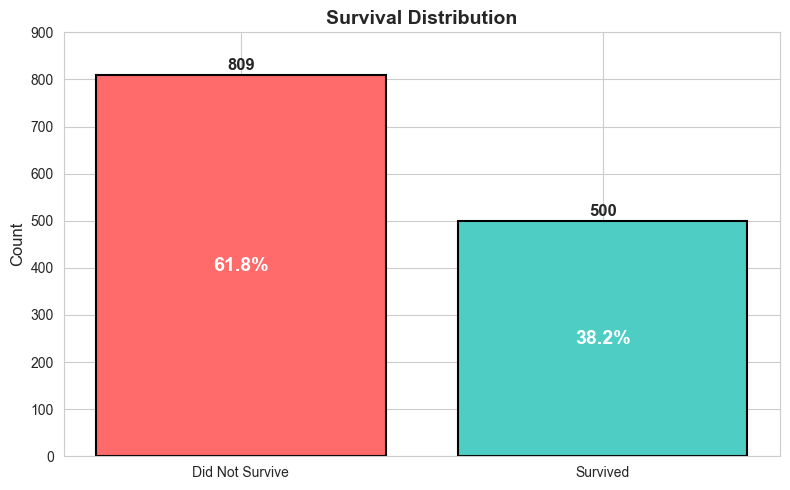

CLASS BALANCE ANALYSIS
Total passengers: 1309
Survived: 500 (38.20%)
Did not survive: 809 (61.80%)

Verdict: The dataset is MILDLY IMBALANCED with ~38% survival rate.
This is typical for Titanic data and not severe enough to require resampling.


In [15]:
# ============================================================================
# CELL: Target Distribution and Class Balance
# ============================================================================

fig, ax = plt.subplots(figsize=(8, 5))
survived_counts = y.value_counts()
colors = ["#FF6B6B", "#4ECDC4"]
bars = ax.bar(
    ["Did Not Survive", "Survived"],
    survived_counts.values,
    color=colors,
    edgecolor="black",
    linewidth=1.5,
)
ax.set_ylabel("Count", fontsize=12)
ax.set_title("Survival Distribution", fontsize=14, fontweight="bold")
ax.set_ylim(0, 900)

# Add count labels on bars
for bar, count in zip(bars, survived_counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 10,
        str(count),
        ha="center",
        fontweight="bold",
        fontsize=12,
    )

# Add percentage labels
total = len(y)
for i, (label, count) in enumerate(survived_counts.items()):
    pct = (count / total) * 100
    ax.text(
        i,
        count / 2,
        f"{pct:.1f}%",
        ha="center",
        va="center",
        fontsize=14,
        color="white",
        fontweight="bold",
    )

plt.tight_layout()
plt.savefig("../figures/target_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

print("=" * 50)
print("CLASS BALANCE ANALYSIS")
print("=" * 50)
print(f"Total passengers: {len(y)}")
print(f"Survived: {survived_counts[1]} ({survived_counts[1] / len(y) * 100:.2f}%)")
print(
    f"Did not survive: {survived_counts[0]} ({survived_counts[0] / len(y) * 100:.2f}%)"
)
print("\nVerdict: The dataset is MILDLY IMBALANCED with ~38% survival rate.")
print("This is typical for Titanic data and not severe enough to require resampling.")

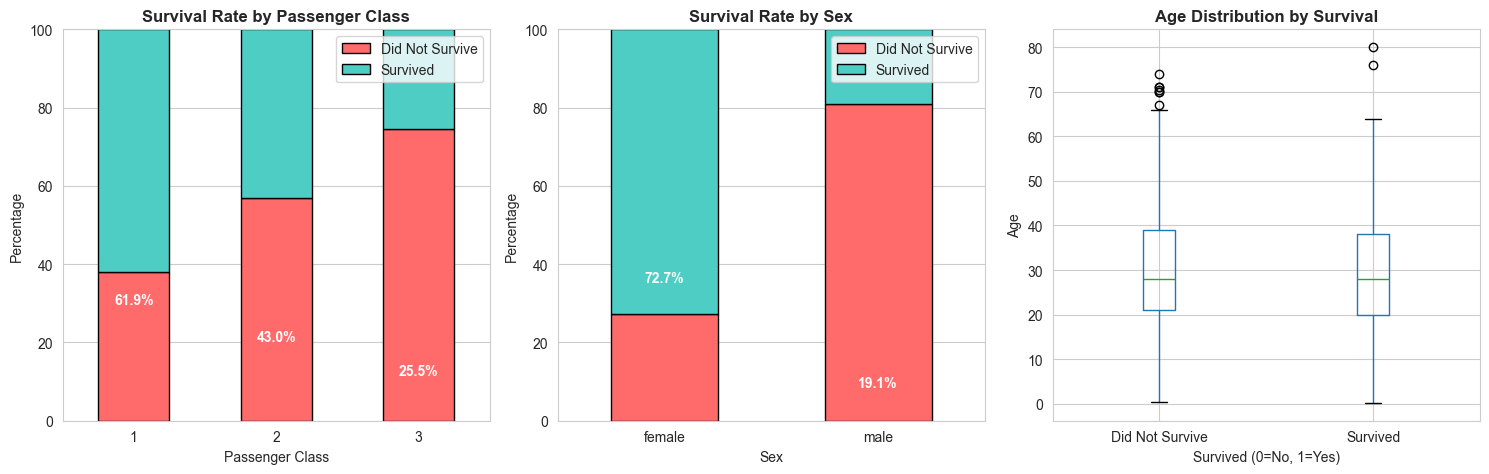

Observations:
1. PCLASS: Higher class passengers had significantly higher survival rates (1st class: ~63%, 3rd class: ~24%)
2. SEX: Females had much higher survival rate (~74%) compared to males (~19%)
3. AGE: Younger children (under 10) and older adults had different survival patterns


In [16]:
# ============================================================================
# CELL: Feature vs Target Investigations (3 plots)
# ============================================================================

# Plot 1: Survival by Passenger Class
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Pclass vs Survival
pclass_survival = pd.crosstab(df["pclass"], y, normalize="index") * 100
pclass_survival.plot(
    kind="bar",
    stacked=True,
    ax=axes[0],
    color=["#FF6B6B", "#4ECDC4"],
    edgecolor="black",
)
axes[0].set_title("Survival Rate by Passenger Class", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Passenger Class")
axes[0].set_ylabel("Percentage")
axes[0].set_ylim(0, 100)
axes[0].legend(["Did Not Survive", "Survived"], loc="upper right")
axes[0].tick_params(axis="x", rotation=0)

# Add percentage labels
for i, (idx, row) in enumerate(pclass_survival.iterrows()):
    axes[0].text(
        i,
        row[1] / 2,
        f"{row[1]:.1f}%",
        ha="center",
        va="center",
        fontsize=10,
        color="white",
        fontweight="bold",
    )

# Plot 2: Survival by Sex
sex_survival = pd.crosstab(df["sex"], y, normalize="index") * 100
sex_survival.plot(
    kind="bar",
    stacked=True,
    ax=axes[1],
    color=["#FF6B6B", "#4ECDC4"],
    edgecolor="black",
)
axes[1].set_title("Survival Rate by Sex", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Sex")
axes[1].set_ylabel("Percentage")
axes[1].set_ylim(0, 100)
axes[1].legend(["Did Not Survive", "Survived"], loc="upper right")
axes[1].tick_params(axis="x", rotation=0)

for i, (idx, row) in enumerate(sex_survival.iterrows()):
    axes[1].text(
        i,
        row[1] / 2,
        f"{row[1]:.1f}%",
        ha="center",
        va="center",
        fontsize=10,
        color="white",
        fontweight="bold",
    )

# Plot 3: Age Distribution by Survival
df_clean = df.copy()
df_clean["survived"] = y
df_clean[df_clean["age"].notna()].boxplot(column="age", by="survived", ax=axes[2])
axes[2].set_title("Age Distribution by Survival", fontsize=12, fontweight="bold")
axes[2].set_xlabel("Survived (0=No, 1=Yes)")
axes[2].set_ylabel("Age")
axes[2].set_xticklabels(["Did Not Survive", "Survived"])

plt.suptitle("")
plt.tight_layout()
plt.savefig(
    "../figures/feature_target_investigations.png", dpi=300, bbox_inches="tight"
)
plt.show()

print("Observations:")
print(
    "1. PCLASS: Higher class passengers had significantly higher survival rates (1st class: ~63%, 3rd class: ~24%)"
)
print("2. SEX: Females had much higher survival rate (~74%) compared to males (~19%)")
print(
    "3. AGE: Younger children (under 10) and older adults had different survival patterns"
)

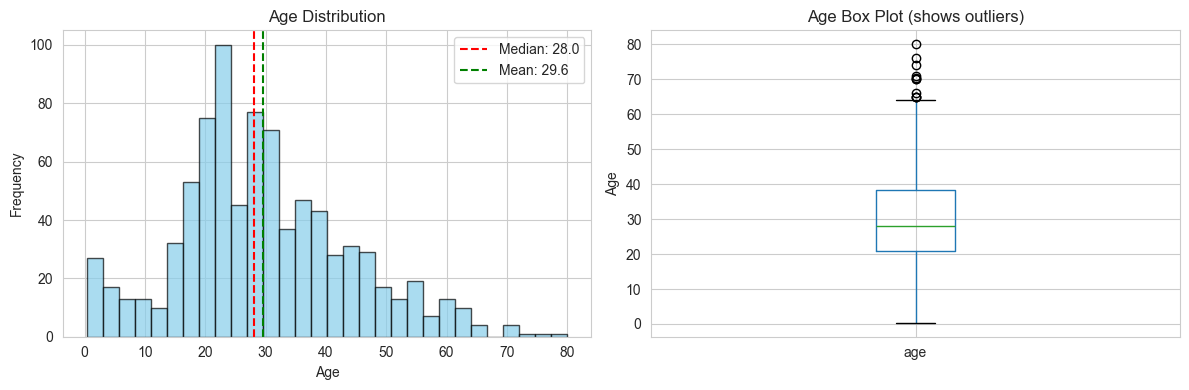

Age Statistics:
  Mean: 29.60
  Median: 28.00
  Std Dev: 14.36
  Skewness: 0.44


In [17]:
# ============================================================================
# CELL 8: Age Distribution Visualization
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram with KDE
axes[0].hist(
    X_train_clean["age"].dropna(),
    bins=30,
    edgecolor="black",
    alpha=0.7,
    color="skyblue",
)
axes[0].axvline(
    X_train_clean["age"].median(),
    color="red",
    linestyle="--",
    label=f"Median: {X_train_clean['age'].median():.1f}",
)
axes[0].axvline(
    X_train_clean["age"].mean(),
    color="green",
    linestyle="--",
    label=f"Mean: {X_train_clean['age'].mean():.1f}",
)
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Age Distribution")
axes[0].legend()

# Box plot to show outliers
X_train_clean.boxplot(column="age", ax=axes[1])
axes[1].set_title("Age Box Plot (shows outliers)")
axes[1].set_ylabel("Age")

plt.tight_layout()
plt.savefig("../figures/age_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

print("Age Statistics:")
print(f"  Mean: {X_train_clean['age'].mean():.2f}")
print(f"  Median: {X_train_clean['age'].median():.2f}")
print(f"  Std Dev: {X_train_clean['age'].std():.2f}")
print(f"  Skewness: {X_train_clean['age'].skew():.2f}")

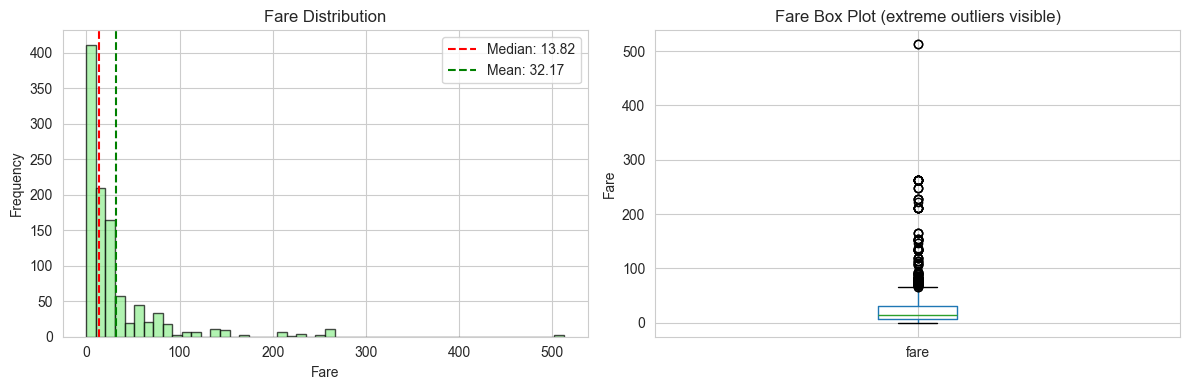

Fare Statistics:
  Mean: $32.17
  Median: $13.82
  Max: $512.33
  Skewness: 4.14


In [18]:
# ============================================================================
# CELL 9: Fare Distribution Visualization
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram with KDE
axes[0].hist(
    X_train_clean["fare"].dropna(),
    bins=50,
    edgecolor="black",
    alpha=0.7,
    color="lightgreen",
)
axes[0].axvline(
    X_train_clean["fare"].median(),
    color="red",
    linestyle="--",
    label=f"Median: {X_train_clean['fare'].median():.2f}",
)
axes[0].axvline(
    X_train_clean["fare"].mean(),
    color="green",
    linestyle="--",
    label=f"Mean: {X_train_clean['fare'].mean():.2f}",
)
axes[0].set_xlabel("Fare")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Fare Distribution")
axes[0].legend()

# Box plot to show extreme outliers
X_train_clean.boxplot(column="fare", ax=axes[1])
axes[1].set_title("Fare Box Plot (extreme outliers visible)")
axes[1].set_ylabel("Fare")

plt.tight_layout()
plt.savefig("../figures/fare_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

print("Fare Statistics:")
print(f"  Mean: ${X_train_clean['fare'].mean():.2f}")
print(f"  Median: ${X_train_clean['fare'].median():.2f}")
print(f"  Max: ${X_train_clean['fare'].max():.2f}")
print(f"  Skewness: {X_train_clean['fare'].skew():.2f}")

=== FARE TRANSFORMATION ===

Original Fare Skewness: 4.14
Log Transformed Fare Skewness: 0.60


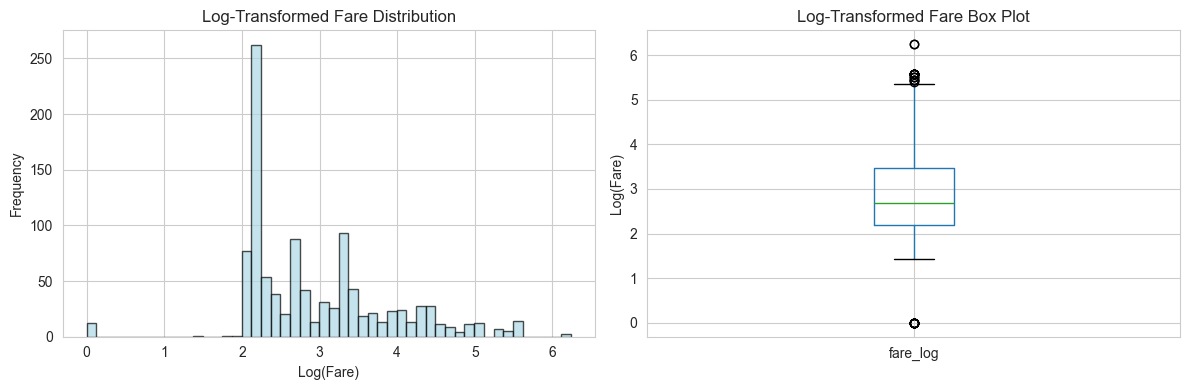

In [19]:
# ============================================================================
# CELL 10: Log Transform for Fare (Address Skewness)
# ============================================================================

# Log transform to normalize skewed distribution
X_train_clean["fare_log"] = np.log1p(X_train_clean["fare"])

print("=== FARE TRANSFORMATION ===\n")
print(f"Original Fare Skewness: {X_train_clean['fare'].skew():.2f}")
print(f"Log Transformed Fare Skewness: {X_train_clean['fare_log'].skew():.2f}")

# Visualize transformed fare
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(
    X_train_clean["fare_log"].dropna(),
    bins=50,
    edgecolor="black",
    alpha=0.7,
    color="lightblue",
)
axes[0].set_xlabel("Log(Fare)")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Log-Transformed Fare Distribution")

X_train_clean.boxplot(column="fare_log", ax=axes[1])
axes[1].set_title("Log-Transformed Fare Box Plot")
axes[1].set_ylabel("Log(Fare)")

plt.tight_layout()
plt.savefig("../figures/fare_log_transformed.png", dpi=300, bbox_inches="tight")
plt.show()

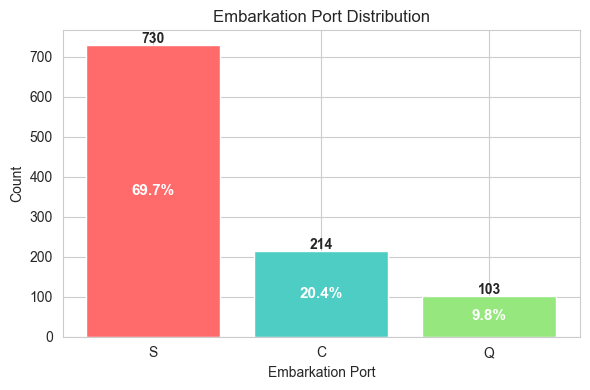

Embarked Value Counts:
  S: 730 (69.7%)
  C: 214 (20.4%)
  Q: 103 (9.8%)

Mode: 'S' (69.7% of passengers)


In [20]:
# ============================================================================
# CELL 11: Embarked Distribution Visualization
# ============================================================================

fig, ax = plt.subplots(figsize=(6, 4))

embarked_counts = X_train_clean["embarked"].value_counts()
colors = ["#FF6B6B", "#4ECDC4", "#95E77E"]
bars = ax.bar(embarked_counts.index, embarked_counts.values, color=colors)
ax.set_xlabel("Embarkation Port")
ax.set_ylabel("Count")
ax.set_title("Embarkation Port Distribution")

# Add count labels on bars
for bar, count in zip(bars, embarked_counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        str(count),
        ha="center",
        fontweight="bold",
    )

# Add percentage labels
total = len(X_train_clean["embarked"].dropna())
for i, (port, count) in enumerate(embarked_counts.items()):
    pct = (count / total) * 100
    ax.text(
        i,
        count / 2,
        f"{pct:.1f}%",
        ha="center",
        va="center",
        fontsize=11,
        color="white",
        fontweight="bold",
    )

plt.tight_layout()
plt.savefig("../figures/embarked_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

print("Embarked Value Counts:")
for port, count in embarked_counts.items():
    print(f"  {port}: {count} ({count / total * 100:.1f}%)")

mode_port = X_train_clean["embarked"].mode()[0]
print(
    f"\nMode: '{mode_port}' ({embarked_counts[mode_port] / total * 100:.1f}% of passengers)"
)

In [21]:
# ============================================================================
# CELL 12: Normality Tests (Statistical Justification)
# ============================================================================

print("=" * 60)
print("NORMALITY TESTS")
print("=" * 60)

# Test for Age
age_data = X_train_clean["age"].dropna()
shapiro_age = stats.shapiro(age_data)
ks_age = stats.kstest(age_data, "norm", args=(age_data.mean(), age_data.std()))

print("\n📊 AGE Normality Tests:")
print(
    f"  Shapiro-Wilk test: statistic={shapiro_age.statistic:.4f}, p-value={shapiro_age.pvalue:.4e}"
)
print(
    f"  Kolmogorov-Smirnov test: statistic={ks_age.statistic:.4f}, p-value={ks_age.pvalue:.4e}"
)

if shapiro_age.pvalue < 0.05:
    print("  → Age is NOT normally distributed (p < 0.05)")
    print("  → Justifies using MEDIAN instead of mean for imputation")
else:
    print("  → Age appears normally distributed")

# Test for Fare
fare_data = X_train_clean["fare"].dropna()
shapiro_fare = stats.shapiro(fare_data)
ks_fare = stats.kstest(fare_data, "norm", args=(fare_data.mean(), fare_data.std()))

print("\n💰 FARE Normality Tests:")
print(
    f"  Shapiro-Wilk test: statistic={shapiro_fare.statistic:.4f}, p-value={shapiro_fare.pvalue:.4e}"
)
print(
    f"  Kolmogorov-Smirnov test: statistic={ks_fare.statistic:.4f}, p-value={ks_fare.pvalue:.4e}"
)

if shapiro_fare.pvalue < 0.05:
    print("  → Fare is NOT normally distributed (p < 0.05)")
    print("  → Justifies using MEDIAN instead of mean for imputation")
else:
    print("  → Fare appears normally distributed")

NORMALITY TESTS

📊 AGE Normality Tests:
  Shapiro-Wilk test: statistic=0.9787, p-value=1.0295e-09
  Kolmogorov-Smirnov test: statistic=0.0749, p-value=1.5439e-04
  → Age is NOT normally distributed (p < 0.05)
  → Justifies using MEDIAN instead of mean for imputation

💰 FARE Normality Tests:
  Shapiro-Wilk test: statistic=0.5394, p-value=6.7613e-46
  Kolmogorov-Smirnov test: statistic=0.2851, p-value=9.6787e-76
  → Fare is NOT normally distributed (p < 0.05)
  → Justifies using MEDIAN instead of mean for imputation


In [22]:
# ============================================================================
# REFACTORED CLEANING & IMPUTATION SEQUENCE
# ============================================================================

# 1. Impute categorical Embarked with its Mode
mode_embarked = X_train_clean["embarked"].mode()[0]
X_train_clean["embarked"] = X_train_clean["embarked"].fillna(mode_embarked)

# 2. Impute raw Fare with its Median
median_fare = X_train_clean["fare"].median()
X_train_clean["fare"] = X_train_clean["fare"].fillna(median_fare)

# 3. NOW calculate fare_log safely on non-null data
X_train_clean["fare_log"] = np.log1p(X_train_clean["fare"])

# 4. Multi-tier Group Imputation for Age (Using Title + Pclass + Sex)
fine_age_medians = X_train_clean.groupby(["pclass", "sex", "title"])["age"].transform(
    "median"
)
coarse_age_medians = X_train_clean.groupby(["pclass", "sex"])["age"].transform("median")
X_train_clean["age"] = (
    X_train_clean["age"].fillna(fine_age_medians).fillna(coarse_age_medians)
)

In [23]:
# ============================================================================
# CELL: Final Encoding and Feature Matrix (FIXED)
# ============================================================================

# Make a copy of the ORIGINAL dataframe with the target
df_clean = df.copy()
df_clean["survived"] = y

# 1. Encode sex (binary)
df_clean["sex"] = df_clean["sex"].map({"male": 0, "female": 1})

# 2. One-hot encode embarked
embarked_dummies = pd.get_dummies(
    df_clean["embarked"], prefix="embarked", drop_first=True, dtype=int
)
df_clean = pd.concat([df_clean, embarked_dummies], axis=1)

# 3. Create final feature matrix (drop non-feature columns)
columns_to_drop = ["name", "ticket", "cabin", "boat", "body", "home.dest", "embarked"]
df_clean = df_clean.drop(
    columns=[col for col in columns_to_drop if col in df_clean.columns]
)

# 4. Handle remaining missing values
# Age imputation (by pclass and sex)
age_medians = df_clean.groupby(["pclass", "sex"])["age"].transform("median")
df_clean["age"] = df_clean["age"].fillna(age_medians)

# Fare imputation (global median)
df_clean["fare"] = df_clean["fare"].fillna(df_clean["fare"].median())

# 5. Create X and y
X = df_clean.drop("survived", axis=1)
y = df_clean["survived"]

print("=" * 50)
print("FINAL FEATURE MATRIX")
print("=" * 50)
print(f"Number of samples (N): {X.shape[0]}")
print(f"Number of features (p): {X.shape[1]}")
print(f"\nFeatures: {list(X.columns)}")
print(f"\nMissing values after imputation: {X.isnull().sum().sum()}")

# 6. Save cleaned data
df_clean.to_csv("../titanic_cleaned.csv", index=False)
np.save("../X_full.npy", X.values)
np.save("../y_full.npy", y.values)

print("\n✅ Saved cleaned data:")
print("   - titanic_cleaned.csv")
print("   - X_full.npy")
print("   - y_full.npy")

FINAL FEATURE MATRIX
Number of samples (N): 1309
Number of features (p): 8

Features: ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked_Q', 'embarked_S']

Missing values after imputation: 0

✅ Saved cleaned data:
   - titanic_cleaned.csv
   - X_full.npy
   - y_full.npy
